My First Regression Project on House price Prediction


In [1]:
import pandas as pd
import matplotlib.pyplot as mpt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Classification Algorithms

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#Ensemble

from sklearn.ensemble import RandomForestClassifier

#PCA
from sklearn.decomposition import PCA

#Ensemble Boostin

from sklearn.ensemble import AdaBoostClassifier 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

# Linear Regression 

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso

from sklearn.ensemble import StackingRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import GradientBoostingRegressor

#classification measuring

from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.mixture import GaussianMixture

#IF there is imbalance in classes

from imblearn.over_sampling import ADASYN,RandomOverSampler,SMOTE
from scipy import stats
from imblearn.under_sampling import RandomUnderSampler,EditedNearestNeighbours

In [45]:
data_file=pd.read_csv("house_price_regression_dataset.csv")

In [46]:
data_file

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [47]:
data_file.isna().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [48]:
data_file.dtypes

Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object

In [42]:
data_file.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [52]:
X=data_file.iloc[:,0:7]

In [53]:
X


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.599637,0,5
1,4272,3,3,2016,4.753014,1,6
2,3592,1,2,2016,3.634823,0,9
3,966,1,2,1977,2.730667,1,8
4,4926,2,1,1993,4.699073,0,8
...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10
996,3179,1,2,1999,2.977123,1,10
997,2606,4,2,1962,4.055067,0,2
998,4723,5,2,1950,1.930921,0,7


In [54]:
scaling=StandardScaler()
X=scaling.fit_transform(X)

In [55]:
data=pd.DataFrame(X,columns=["Square_Footage","Num_Bedrooms","Num_Bathrooms","Year_Built","Lot_Size","Garage_Size","Neighborhood_Quality"])

In [56]:
X

array([[-1.15980323, -0.69383623, -1.18669921, ..., -1.67927849,
        -1.25465753, -0.21312613],
       [ 1.16072443,  0.00700845,  1.25255918, ...,  1.52238989,
        -0.02700828,  0.13342042],
       [ 0.61884297, -1.39468091,  0.03292999, ...,  0.66042215,
        -1.25465753,  1.17306009],
       ...,
       [-0.16688515,  0.70785312,  0.03292999, ...,  0.98437109,
        -1.25465753, -1.25276579],
       [ 1.52011933,  1.4086978 ,  0.03292999, ..., -0.65304553,
        -1.25465753,  0.47996698],
       [ 0.36065239,  0.70785312,  0.03292999, ...,  0.25492526,
         1.20064096, -1.25276579]], shape=(1000, 7))

In [57]:
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,-1.159803,-0.693836,-1.186699,-0.269122,-1.679278,-1.254658,-0.213126
1,1.160724,0.007008,1.252559,1.428045,1.522390,-0.027008,0.133420
2,0.618843,-1.394681,0.032930,1.428045,0.660422,-1.254658,1.173060
3,-1.473776,-1.394681,0.032930,-0.463084,-0.036555,-0.027008,0.826514
4,1.681887,-0.693836,-1.186699,0.312764,1.480809,-1.254658,0.826514
...,...,...,...,...,...,...,...
995,0.355074,0.707853,-1.186699,-0.414594,-0.472519,1.200641,1.519607
996,0.289730,-1.394681,0.032930,0.603707,0.153428,-0.027008,1.519607
997,-0.166885,0.707853,0.032930,-1.190442,0.984371,-1.254658,-1.252766
998,1.520119,1.408698,0.032930,-1.772328,-0.653046,-1.254658,0.479967


In [58]:
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,-2.220446e-17,-1.847411e-16,-1.421085e-16,2.209788e-15,3.552714e-17,-5.506706e-17,-1.048051e-16
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-1.842733e+00,-1.394681e+00,-1.186699e+00,-1.772328e+00,-1.751414e+00,-1.254658e+00,-1.599312e+00
25%,-8.494167e-01,-6.938362e-01,-1.186699e+00,-8.510082e-01,-8.573045e-01,-1.254658e+00,-9.062192e-01
50%,3.751573e-02,7.008447e-03,3.292999e-02,-2.666977e-02,2.439999e-02,-2.700828e-02,1.334204e-01
75%,8.240407e-01,7.078531e-01,1.252559e+00,8.582818e-01,8.828109e-01,1.200641e+00,8.265135e-01
max,1.740059e+00,1.408698e+00,1.252559e+00,1.718988e+00,1.704535e+00,1.200641e+00,1.519607e+00


In [64]:
Y=data_file.iloc[:,7:8]

In [65]:
Y

,House_Price
0,2.623829e+05
1,9.852609e+05
2,7.779774e+05
3,2.296989e+05
4,1.041741e+06
...,...
995,7.014940e+05
996,6.837232e+05
997,5.720240e+05
998,9.648653e+05


In [66]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=20)

Lets move on to Applying the Regression algorithms

In [67]:
LR=LinearRegression()
LR_model=LR.fit(X_train,y_train)

In [68]:
LR_model.score(X_test,y_test)

0.998601246393702

In [70]:
y_predict=LR_model.predict(X_test)
y_predict

array([[ 845438.54045898],
       [ 459339.75926854],
       [ 856242.78307404],
       [ 726724.63533513],
       [ 759362.91005719],
       [ 207004.18651086],
       [ 834410.37377586],
       [1011595.84711502],
       [ 548948.86822065],
       [ 247730.01499108],
       [ 576435.2563318 ],
       [ 818943.47773895],
       [ 277763.5984574 ],
       [1046923.02388281],
       [ 351299.48349943],
       [ 260525.83830181],
       [ 723786.01073596],
       [ 594057.0930164 ],
       [ 931672.16227875],
       [ 348503.57935488],
       [ 877665.57233835],
       [ 663485.84043577],
       [ 980574.88088328],
       [ 800144.23241974],
       [ 826546.95511771],
       [ 396676.85958422],
       [ 187790.49214885],
       [ 663090.20826582],
       [ 893646.41838076],
       [ 540159.19934631],
       [ 831018.99935514],
       [ 828314.77722114],
       [ 723210.41207373],
       [ 371112.27521176],
       [ 879664.29153868],
       [ 697486.18300738],
       [ 834737.60107399],
 

In [72]:
absolute_mean=mean_absolute_error(y_test,y_predict)

In [73]:
absolute_mean

7274.795259536363

In [77]:
absolute_mean_squared=mean_squared_error(y_test,y_predict)
absolute_mean_squared


85255001.49752045

In [79]:
r_score=r2_score(y_test,y_predict)
r_score


0.998601246393702

In [80]:
LR_model.coef_

array([[250716.41838813,  14424.97395095,   6922.9863424 ,
         20240.05170987,  19362.57651479,   4147.81534518,
           316.33618623]])

In [81]:
LR_model.intercept_

array([618547.83008046])

In [83]:
cv_lr=cross_val_score(LR,X_train,y_train,cv=4)

In [85]:
cv_lr.mean()

np.float64(0.9984446750018007)

Lasso Regression


In [86]:
lasso=Lasso(alpha=0.8)
lasso_midel=lasso.fit(X_train,y_train)

In [87]:
lasso_midel.score(X_test,y_test)

0.9986012404076988

In [88]:
lasso_midel.predict(X_test)

array([ 845437.32181176,  459339.6451623 ,  856242.86347534,
        726726.05667905,  759364.36538559,  207004.37949259,
        834405.63722633, 1011592.62624723,  548949.96443258,
        247730.23545379,  576433.7767517 ,  818943.42290892,
        277766.32986007, 1046920.38966388,  351301.00095592,
        260526.69120199,  723783.26208319,  594054.64892584,
        931671.8745152 ,  348505.299269  ,  877664.48336707,
        663485.4090833 ,  980573.17471009,  800140.6590797 ,
        826544.71215348,  396676.29134451,  187794.00504564,
        663090.82034125,  893645.53087778,  540159.28918614,
        831015.64347184,  828315.76108104,  723209.35014159,
        371112.6335336 ,  879662.51605624,  697484.76211171,
        834735.52470205,  679187.56920927,  764420.90013614,
        386381.97314975,  348297.10457663,  516381.73630035,
        729600.85174418,  685002.3883349 ,  729020.68116086,
        303575.87901108,  433045.40660284,  304114.95190321,
        980765.59354202,

In [89]:
from sklearn.model_selection import RandomizedSearchCV

In [103]:
parameter_array_lasso=[{"alpha":[0.1,0.6,0.90,0.66]}]

lasso_search=GridSearchCV(lasso,parameter_array_lasso,cv=10,n_jobs=-1)

In [104]:
lasso_fit=lasso_search.fit(X_train,y_train)

In [105]:
lasso_fit.best_params_

{'alpha': 0.6}

In [106]:
lasso_fit.score(X_test,y_test)

0.9986012417695217

Ridge Regression 

In [102]:
parameter_array_ridge=[{"alpha":[0.1,0.6,0.90,0.66]}]

random_search=RandomizedSearchCV(lasso,parameter_array_ridge,cv=10,n_jobs=-1)

In [107]:
ridge=Ridge(alpha=0.88)
fir_ridge=ridge.fit(X_train,y_train)


In [108]:
fir_ridge.score(X_test,y_test)

0.9986015041745188

In [113]:
parameter_array_ridge=[{"alpha":[0.1,0.6,0.90,0.66,0.3,0.5,0.2,0.555,0.32,0.4,0.532]}]

random_search=RandomizedSearchCV(ridge,parameter_array_ridge,cv=4,n_jobs=-1)

In [114]:
random_search_model=random_search.fit(X_train,y_train)

In [115]:
random_search_model.score(X_test,y_test)

0.998601510696154

Elastice regressino

In [122]:
elastic_reg=ElasticNet()
elastic_model=elastic_reg.fit(X_train,y_train)

In [121]:
elastic_model.score(X_test,y_test)

0.9718593735450588

In [123]:
parameter_array_elastic=[{"alpha":[0.1,0.6,0.90,0.66,0.3,0.5,0.2,0.555,0.32,0.4,0.532],"l1_ratio":[0.1,0.6,0.90,0.66,0.3,0.5,0.2,0.555,0.32,0.4,0.532]}]

random_search_elastic=RandomizedSearchCV(elastic_reg,parameter_array_elastic,cv=4,n_jobs=-1)

In [124]:
random_search_elastic.fit(X_train,y_train)

,estimator,ElasticNet()
,param_distributions,"[{'alpha': [0.1, 0.6, ...], 'l1_ratio': [0.1, 0.6, ...]}]"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [125]:
random_search_elastic.score(X_test,y_test)

0.9955683137457899

In [131]:
random_forest=RandomForestRegressor(n_estimators=30,max_depth=10,min_samples_leaf=10,n_jobs=-1)

In [132]:
random_foret_regre=random_forest.fit(X_train,y_train)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [133]:
random_foret_regre.score(X_test,y_test)

0.9885539980835779

Stacking Regression 

In [142]:
stacking=StackingRegressor(estimators=[
    ("elastic_reg",elastic_reg),
    ("ridge",ridge),
    ("lasso",lasso) ],
    final_estimator=random_forest,cv=5)

In [143]:
stacking_fit_model=stacking.fit(X_train,y_train)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\ensemble\_stacking.py:1041: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [144]:
stacking_fit_model.score(X_test,y_test)

0.9982426001086467

In [145]:
isolation=IsolationForest(n_estimators=20,max_samples=5)

In [146]:
isolation_fit=isolation.fit(X_train,y_train)

In [148]:
isolation_fit.predict(X_test)

array([-1,  1, -1, -1,  1, -1,  1, -1, -1,  1,  1,  1, -1, -1,  1,  1,  1,
       -1, -1,  1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1, -1,  1, -1,  1,
        1, -1, -1,  1, -1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1,  1,  1,
        1, -1, -1,  1,  1, -1, -1, -1, -1,  1, -1,  1,  1,  1,  1,  1, -1,
       -1,  1, -1,  1,  1,  1,  1, -1, -1,  1, -1, -1, -1,  1, -1, -1, -1,
        1, -1,  1,  1,  1,  1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1,
        1, -1, -1, -1, -1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1, -1, -1,
        1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1,  1, -1, -1,
        1, -1,  1, -1, -1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1, -1, -1,
        1,  1, -1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1,  1, -1, -1,  1, -1, -1, -1,  1, -1, -1, -1, -1, -1,  1, -1,  1,
        1,  1,  1,  1,  1, -1,  1, -1, -1, -1, -1,  1,  1])

UNSUPERVISED LEARNING


In [149]:
unsuper_data=pd.read_csv("Customer Data.csv")

In [150]:
unsuper_data.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [155]:
unsuper_data=unsuper_data.drop(columns="CUST_ID")

In [156]:
unsuper_data

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [157]:
unsuper_data.dtypes

BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [ ]:
unsuper_data.isna().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [160]:
remove_na=SimpleImputer(strategy='mean')


In [163]:
unsuper_data[["MINIMUM_PAYMENTS"]]=remove_na.fit_transform(unsuper_data[["MINIMUM_PAYMENTS"]])
unsuper_data[["CREDIT_LIMIT"]]=remove_na.fit_transform(unsuper_data[["CREDIT_LIMIT"]])

In [164]:
unsuper_data.head(10)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [165]:
unsuper_data.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.612411,2895.063757,2330.588021,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,335.628312,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,864.206542,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [166]:
standarizing_unsuper_data=StandardScaler()
unsuper_fit_data=standarizing_unsuper_data.fit_transform(unsuper_data)

In [167]:
unsuper_fit_data

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.31096755,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.08931021,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.10166318,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.33546549,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.34690648,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.33294642,
        -0.52555097, -4.12276757]], shape=(8950, 17))

In [170]:
finance_data=pd.DataFrame(unsuper_fit_data,columns=["BALANCE","BALANCE_FREQUENCY","PURCHASES","ONEOFF_PURCHASES","INSTALLMENTS_PURCHASES","CASH_ADVANCE","PURCHASES_FREQUENCY","ONEOFF_PURCHASES_FREQUENCY","PURCHASES_INSTALLMENTS_FREQUENCY","CASH_ADVANCE_FREQUENCY","CASH_ADVANCE_TRX","PURCHASES_TRX","CREDIT_LIMIT","PAYMENTS","MINIMUM_PAYMENTS","PRC_FULL_PAYMENT","TENURE"])

In [171]:
finance_data.head(10)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-0.310968,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,0.089310,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-0.101663,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,0.000000,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-0.265791,-0.525551,0.36068
5,0.117878,0.518084,0.154492,-0.356934,1.019822,-0.466786,0.439310,-0.678661,0.550784,-0.675349,-0.476070,-0.269945,-0.740557,-0.115060,0.662119,-0.525551,0.36068
6,-0.450277,0.518084,2.849408,3.500548,0.306664,-0.466786,1.269843,2.673451,1.599199,-0.675349,-0.476070,1.983008,2.475134,1.596313,-0.285841,2.893453,0.36068
7,0.124520,0.518084,-0.265388,-0.356934,0.027792,-0.466786,1.269843,-0.678661,1.599199,-0.675349,-0.476070,-0.109020,-0.603134,-0.364116,-0.142535,-0.525551,0.36068
8,-0.264026,0.518084,-0.066330,0.041603,-0.233408,-0.466786,-0.391225,-0.399319,-0.287947,-0.675349,-0.476070,-0.390639,0.688639,-0.360933,-0.236968,-0.525551,0.36068
9,-0.678504,-1.400712,0.130303,0.415209,-0.454576,-0.466786,-0.806490,-0.119974,-0.916995,-0.675349,-0.476070,-0.471102,1.788021,-0.196336,-0.327792,-0.525551,0.36068


In [172]:
pca=PCA(10)

In [181]:
pca_fit=pca.fit_transform(finance_data)

In [188]:
gaussian=GaussianMixture(n_components=10,random_state=40)

In [189]:
gaussian.fit(pca_fit)

,n_components,10
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,40


In [192]:
predict_gauss=gaussian.predict([[10598.46777,
1,
2084.48,
1300.48,
784,
0,
0.666667,
0.416667,
0.583333,0.416667]])

In [198]:
predict_gauss_2=gaussian.predict(pca_fit)

In [194]:
predict_gauss.mean()

np.float64(6.0)

In [196]:
proba=gaussian.predict_proba([[10598.46777,
1,
2084.48,
1300.48,
784,
0,
0.666667,
0.416667,
0.583333,0.416667]])  

In [197]:
proba

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])

In [200]:
mean_gauss=gaussian.means_

ValueError: too many values to unpack (expected 2)

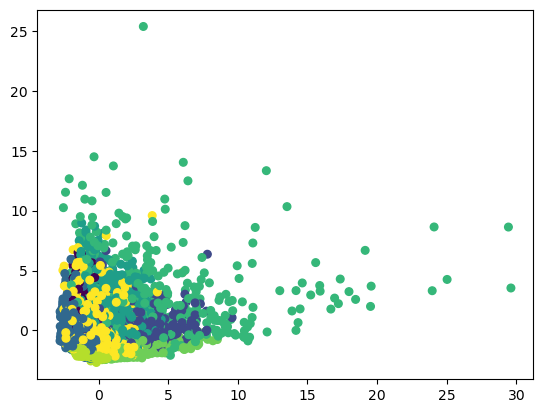

In [204]:
mpt.scatter(pca_fit[:, 0], pca_fit[:, 1], c=predict_gauss_2, cmap='viridis', s=30, label='Cluster Points')

# Annotate cluster centers with their labels
for idx, (x, y) in enumerate(mean_gauss):
    mpt.text(x, y, str(idx), color="black", fontsize=12, ha="center", va="center",
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

# Add title and legend
mpt.title("GMM Clustering Predictions with Cluster Labels")
mpt.show()

In [205]:
from sklearn.neighbors import LocalOutlierFactor


In [206]:
outlier=LocalOutlierFactor(20)
outlier_find=outlier.fit_predict(pca_fit)

In [207]:
outlier_find

array([1, 1, 1, ..., 1, 1, 1], shape=(8950,))